In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import rcParams
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

## Exploratory Data Analysis (EDA)

In [68]:
# Veri setini yükleme
df = pd.read_csv('online_shoppers_intention.csv')
# veri setinin ilk beş satırı
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [69]:
# Veri setinin bilgileri
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [70]:
# satır ve sütun sayısını görüntüleme
df.shape

(12330, 18)

In [71]:
# tanımlayıcı istatistikler
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [72]:
# Eksik değer kontrolü
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Yinelenen satırlar (duplicates), modelin belirli gözlemlere aşırı duyarlı hale gelmesine (overfitting) neden olabilir. Veri bütünlüğü için bu satırlar veri setinden arındırılmıştır.

In [73]:
# Tekrarlayan satırları kaldırma
df.drop_duplicates(inplace=True)
# tekrar satır ve sütun sayısını kontrol etme
df.shape

(12205, 18)

In [74]:
print(df.Weekend.value_counts())
print(df.Revenue.value_counts())

Weekend
False    9346
True     2859
Name: count, dtype: int64
Revenue
False    10297
True      1908
Name: count, dtype: int64


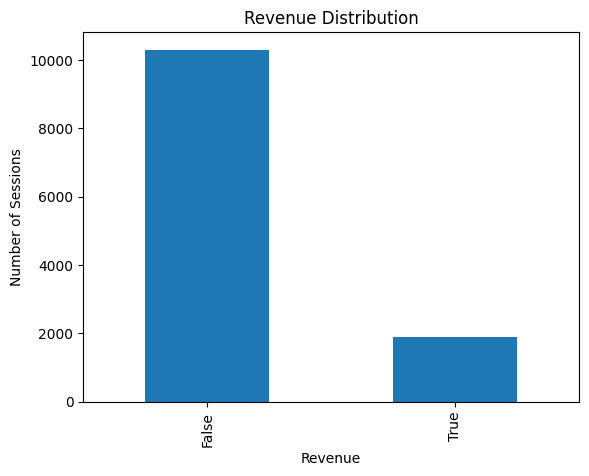

In [75]:
df.Revenue.value_counts().plot(kind='bar')
plt.xlabel('Revenue')
plt.ylabel('Number of Sessions')
plt.title('Revenue Distribution')
plt.show()

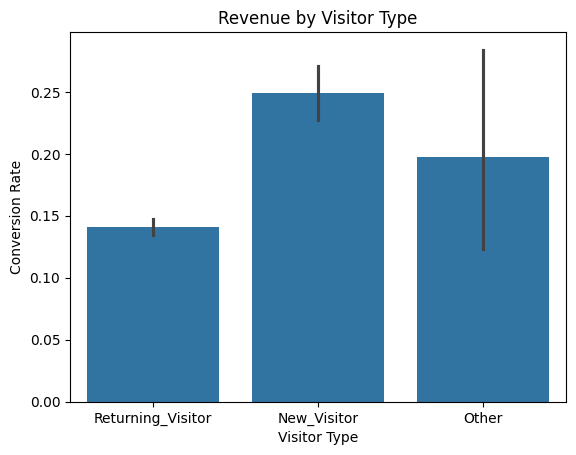

In [91]:
# VisitorType ile Revenue arasındaki ilişkiyi görselleştirme
sns.barplot(x='VisitorType', y='Revenue', data=df)
plt.title('Revenue by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Conversion Rate')
plt.show()

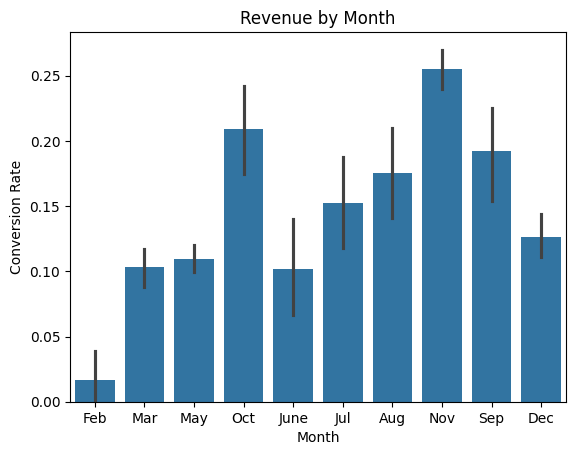

In [92]:
# Month ile Revenue arasındaki ilişkiyi görselleştirme
sns.barplot(x='Month', y='Revenue', data=df)
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Conversion Rate')
plt.show()

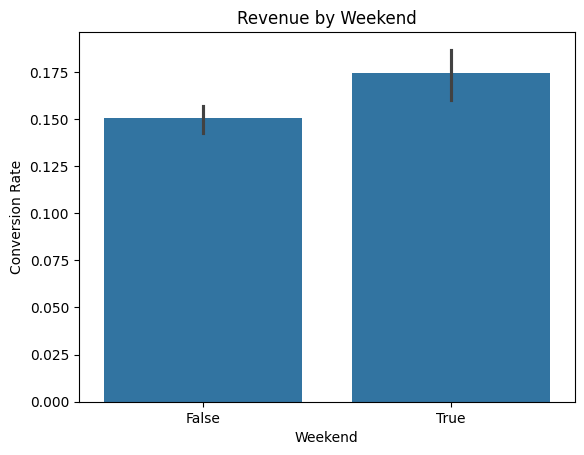

In [93]:
# Weekend ile Revenue arasındaki ilişkiyi görselleştirme
sns.barplot(x='Weekend', y='Revenue', data=df)
plt.title('Revenue by Weekend')
plt.xlabel('Weekend')
plt.ylabel('Conversion Rate')
plt.show()

## Feature Engineering & Preprocessing

In [79]:
# Bağımsız ve bağımlı değişkenlerin ayrılması
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# İşe yaramayan sütunları kaldırma
X.drop('PageValues', axis=1, inplace=True)

# Weekend sütununu integer tipe çevirme
X['Weekend'] = X['Weekend'].astype(int)

# Kategorik değişkenleri ikili değişkenlere dönüştürme
X = pd.get_dummies(X, drop_first=True)
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,1,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,2,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,4,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,3,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,3,...,True,False,False,False,False,False,False,False,False,True


In [80]:
# Sayısal sütunların belirlenmesi
num_cols = ['Administrative_Duration','Informational_Duration',
            'ProductRelated_Duration','BounceRates','ExitRates',
            'SpecialDay'
    ]

# StandardScaler ile sayısal sütunların ölçeklendirilmesi
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

## Model Training

In [81]:
# Verilerin eğitim ve test seti olarak ayrılması
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [82]:
# Hiperparametre ayarları
params = {'C': [0.001, 0.01, 0.1, 1.], 'penalty': ['l1', 'l2']
}
 
# Lojistik regresyon modeli
log_reg = LogisticRegression(random_state=42, class_weight='balanced',solver='liblinear'
    )

# GridSearchCV ile modelin hiperparametrelerini belirleme
log_reg_cv = GridSearchCV(
    log_reg, 
    param_grid=params, 
    cv=5,
    scoring='accuracy',
)
# Modelin eğitilmesi
log_reg_cv.fit(X_train, y_train)

,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


## Model Evaluation

In [83]:
# Tahminlerin yapılması
y_pred = log_reg_cv.predict(X_test)

# En iyi skor ve parametrelerin görüntülenmesi
print('Best score: ', log_reg_cv.best_score_)
print('Best params: ', log_reg_cv.best_params_)
print('Score: ', log_reg_cv.score(X_test, y_test))

Best score:  0.6338532880753909
Best params:  {'C': 1.0, 'penalty': 'l2'}
Score:  0.6381758601856908


In [84]:
y_pred = log_reg_cv.predict(X_test)
# Precision, Recall, F1-score hesaplanması
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.62      0.74      3116
        True       0.25      0.74      0.38       546

    accuracy                           0.64      3662
   macro avg       0.59      0.68      0.56      3662
weighted avg       0.83      0.64      0.69      3662



## ROC Curve

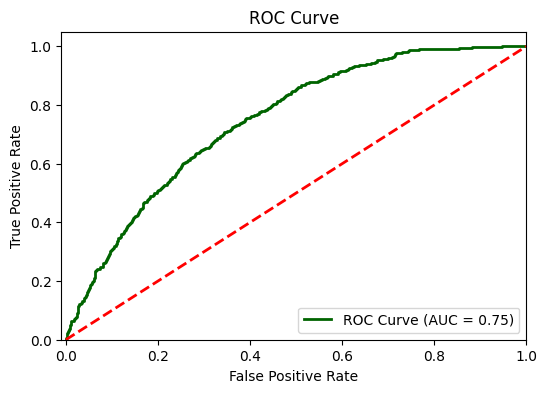

In [88]:
fpr, tpr, thresholds = roc_curve(y_test, log_reg_cv.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Confusion Matrix

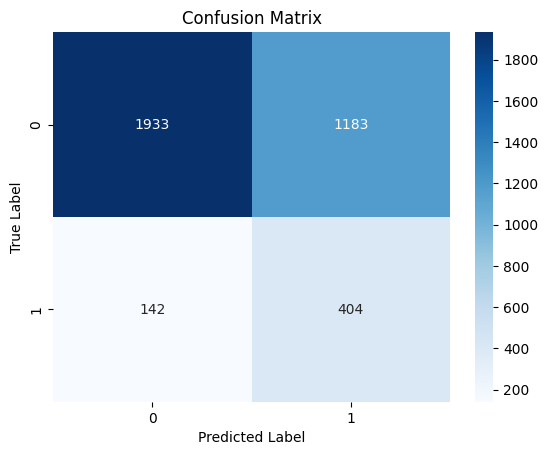

TP: 404, TN: 1933, FP: 1183, FN: 142


In [90]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# TP, TN, FP, FN değerlerinin belirlenmesi
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
